# Olist Regional (SP/MG) Revenue Forecast — Reusing the v2 Methodology, Pacing Only

## Background
In an earlier segment-forecasting experiment (`olist_segment_sales_forecasting.ipynb`):
- All 10 categories had **negative R² even for the naive baseline** → conclusion: category-level forecasting isn't viable
- Only **SP (R²=0.412) and MG (R²=0.245)** beat naive → only these two regions are reliable enough to forecast
- That experiment used a **1-step-ahead (next-day) RandomForest**, so it couldn't produce a 7-day trend or month-end pacing

## Goal of this notebook
Reuse the v2 pipeline built for total revenue (Direct multi-horizon + HGB_ratio + Conformal interval),
adding only a **regional filter**, for SP and MG separately.

Core principles (carried over from the earlier experiment):
- Only **forecast daily, then sum** (re-training at weekly/monthly granularity already failed — sample size collapses)
- SP and MG are each fit as **independent models** (a shared-feature panel had bias issues before)
- The pipeline is unified into one function, `build_regional_pipeline(state_code, state_name)` —
  adding another region later just means calling it again with that region's code

In [13]:
# =========================================================
# Cell 1 - Libraries & raw data load (including customer state)
# =========================================================
import os, time, warnings
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ===== Only this path needs to match your environment =====
PATH = r'C:\Users\Peter\Desktop\Brazilian E-Commerce Public Dataset by Olist'

orders    = pd.read_csv(os.path.join(PATH, "olist_orders_dataset.csv"))
items     = pd.read_csv(os.path.join(PATH, "olist_order_items_dataset.csv"))
customers = pd.read_csv(os.path.join(PATH, "olist_customers_dataset.csv"))

for c in ["order_purchase_timestamp", "order_approved_at",
          "order_delivered_carrier_date", "order_delivered_customer_date",
          "order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

order_revenue = (items.groupby("order_id")
                      .agg(revenue=("price", "sum"), freight=("freight_value", "sum"))
                      .reset_index())
order_revenue["total_revenue"] = order_revenue["revenue"] + order_revenue["freight"]

df = orders.merge(order_revenue, on="order_id", how="inner")
df = df[df["order_status"] == "delivered"].copy()
df["order_date"] = df["order_purchase_timestamp"].dt.date

# ---- attach region (customer state) ----
df = df.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")

state_share = df.groupby("customer_state")["total_revenue"].sum().sort_values(ascending=False)
state_share_pct = (state_share / state_share.sum() * 100).round(1)
print("Top 5 states by revenue share:")
print(state_share_pct.head(5).to_string())

Top 5 states by revenue share:
customer_state
SP    37.4
RJ    13.3
MG    11.8
RS     5.6
PR     5.1


## Calendar/holiday features - shared across regions

Brazil's national holidays and Black Friday are the same regardless of region, so they're
computed once and shared by both the SP and MG pipelines.

In [15]:
# =========================================================
# Cell 2 - Holiday / Black Friday calculation (shared across regions)
# =========================================================
def easter_date(year):
    a, b, c = year % 19, year // 100, year % 100
    d, e = b // 4, b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    hh = (19 * a + b - d - g + 15) % 30
    i, k = c // 4, c % 4
    l = (32 + 2 * e + 2 * i - hh - k) % 7
    m = (a + 11 * hh + 22 * l) // 451
    return date(year, (hh + l - 7 * m + 114) // 31, ((hh + l - 7 * m + 114) % 31) + 1)

FIXED_HOLIDAYS = [(1, 1), (4, 21), (5, 1), (9, 7), (10, 12), (11, 2), (11, 15), (12, 25)]

def brazil_holidays(year):
    d_ = {date(year, m, dd) for m, dd in FIXED_HOLIDAYS}
    e = easter_date(year)
    return d_ | {e - timedelta(days=47), e - timedelta(days=2), e + timedelta(days=60)}

def black_friday(year):
    d0 = date(year, 11, 1)
    thu = [d0 + timedelta(days=i) for i in range(30)
           if (d0 + timedelta(days=i)).month == 11 and (d0 + timedelta(days=i)).weekday() == 3]
    return thu[3] + timedelta(days=1)

YEARS_RANGE = sorted(df["order_purchase_timestamp"].dt.year.unique())
holiday_set = set().union(*[brazil_holidays(y) for y in YEARS_RANGE])
bf_week = set()
for y in YEARS_RANGE:
    bf = black_friday(y)
    bf_week |= {bf + timedelta(days=i) for i in range(6)}

def h_bucket(h):
    if h <= 7:
        return 1
    if h <= 14:
        return 2
    return 3

BUCKET_LABEL = {1: "h1~7", 2: "h8~14", 3: "h15~31"}

print("Holiday set ready:", len(holiday_set), "days | Black Friday week:", len(bf_week), "days")

Holiday set ready: 33 days | Black Friday week: 18 days


## Regional pipeline function

`build_regional_pipeline(state_code, state_name)` handles everything from data filtering
through CV, the final model, and interval calculation. It returns a dict holding that region's
`forecast()` and `month_pacing()` functions, plus diagnostics (`summary`, `cv`, `BEST`, etc.).

**Sample-size safeguard**: regional data is smaller than the full dataset, so some conformal
buckets may have zero observations. In that case the global value is used as a fallback.

In [17]:
# =========================================================
# Cell 3 - Regional pipeline function
# =========================================================
H_MAX = 31
START_DATE, END_DATE = "2017-01-05", "2018-08-21"
CV_START, CV_END, CV_STEP = "2018-01-03", "2018-08-14", 14
MIN_BUCKET_N = 20
ALPHA = 0.20

def make_hgb():
    return HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_bins=64,
        min_samples_leaf=20, l2_regularization=1.0, random_state=42)

def wmape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return np.abs(y - p).sum() / y.sum() * 100

def conformal_q(errs, alpha=ALPHA):
    e = np.abs(np.asarray(errs, float))
    e = e[np.isfinite(e)]
    if len(e) == 0:
        return np.nan
    lvl = min(np.ceil((len(e) + 1) * (1 - alpha)) / len(e), 1.0)
    return np.quantile(e, lvl)


def build_regional_pipeline(state_code, state_name, verbose=True):
    """Apply the full v2 pipeline to data filtered by state_code (e.g. 'SP').
    Returns: dict(forecast=fn, month_pacing=fn, forecast_beyond=fn, month_pacing_beyond=fn, ...)
    """
    t0 = time.time()
    df_r = df[df["customer_state"] == state_code].copy()

    # ---- daily aggregation ----
    daily = (df_r.groupby("order_date")
                 .agg(order_count=("order_id", "nunique"), daily_revenue=("total_revenue", "sum"))
                 .reset_index())
    daily["order_date"] = pd.to_datetime(daily["order_date"])
    daily = daily.sort_values("order_date").reset_index(drop=True)

    full_range = pd.date_range(daily["order_date"].min(), daily["order_date"].max(), freq="D")
    daily_full = (daily[["order_date", "order_count", "daily_revenue"]]
                  .set_index("order_date").reindex(full_range, fill_value=0).reset_index())
    daily_full.columns = ["order_date", "order_count", "daily_revenue"]

    cust_daily = df_r.groupby("order_date").agg(n_customers=("customer_id", "nunique")).reset_index()
    cust_daily["order_date"] = pd.to_datetime(cust_daily["order_date"])
    sell_daily = items.merge(df_r[["order_id", "order_date"]], on="order_id", how="inner")
    sell_daily = sell_daily.groupby("order_date")["seller_id"].nunique().reset_index()
    sell_daily.columns = ["order_date", "n_sellers"]
    sell_daily["order_date"] = pd.to_datetime(sell_daily["order_date"])

    daily_full = (daily_full.merge(cust_daily, on="order_date", how="left")
                            .merge(sell_daily, on="order_date", how="left"))
    daily_full[["n_customers", "n_sellers"]] = daily_full[["n_customers", "n_sellers"]].fillna(0)

    base_r = daily_full[(daily_full["order_date"] >= START_DATE) &
                        (daily_full["order_date"] <= END_DATE)].copy().reset_index(drop=True)

    base_r["dayofweek"]  = base_r["order_date"].dt.dayofweek
    base_r["month"]      = base_r["order_date"].dt.month
    base_r["day"]        = base_r["order_date"].dt.day
    base_r["is_weekend"] = base_r["dayofweek"].isin([5, 6]).astype(int)
    base_r["day_index"]  = (base_r["order_date"] - base_r["order_date"].min()).dt.days
    base_r["is_holiday"] = base_r["order_date"].dt.date.isin(holiday_set).astype(int)
    base_r["is_bf_week"] = base_r["order_date"].dt.date.isin(bf_week).astype(int)
    base_r["dom_pos"]    = base_r["day"] / base_r["order_date"].dt.days_in_month

    # ---- long-format dataset ----
    b_r = base_r.reset_index(drop=True)
    n_r = len(b_r)
    s_r = b_r["daily_revenue"]

    ma7_o   = s_r.rolling(7).mean()
    ma28_o  = s_r.rolling(28).mean()
    std7_o  = s_r.rolling(7).std()
    cust_ma7 = b_r["n_customers"].rolling(7).mean()
    sell_ma7 = b_r["n_sellers"].rolling(7).mean()

    ma7_trail = s_r.shift(1).rolling(7).mean()
    dow_ratio = s_r / ma7_trail
    prof = pd.DataFrame(index=b_r.index, columns=range(7), dtype=float)
    for w in range(7):
        prof[w] = dow_ratio.where(b_r["dayofweek"] == w).expanding(min_periods=1).mean().ffill()
    prof = prof.fillna(1.0)
    prof_arr = prof.values

    rev_r = s_r.values
    frames = []
    for h in range(1, H_MAX + 1):
        t = np.arange(h, n_r)
        o = t - h
        k = 7 * int(np.ceil(h / 7))
        sw = t - k
        ok = sw >= 0
        t, o, sw = t[ok], o[ok], sw[ok]
        dow_t = b_r["dayofweek"].values[t]
        dfac = prof_arr[o, dow_t]

        frames.append(pd.DataFrame({
            "origin_date": b_r["order_date"].values[o], "target_date": b_r["order_date"].values[t],
            "h": h, "weeks_ahead": int(np.ceil(h / 7)),
            "dayofweek": dow_t, "month": b_r["month"].values[t], "day": b_r["day"].values[t],
            "is_weekend": b_r["is_weekend"].values[t], "is_holiday": b_r["is_holiday"].values[t],
            "is_bf_week": b_r["is_bf_week"].values[t], "dom_pos": b_r["dom_pos"].values[t],
            "day_index": b_r["day_index"].values[t],
            "rev_o": rev_r[o], "ma7_o": ma7_o.values[o], "ma28_o": ma28_o.values[o],
            "std7_o": std7_o.values[o],
            "cust_o": b_r["n_customers"].values[o], "sell_o": b_r["n_sellers"].values[o],
            "cust_ma7_o": cust_ma7.values[o], "sell_ma7_o": sell_ma7.values[o],
            "rev_sameweek": rev_r[sw], "dow_factor": dfac,
            "expected_level": ma28_o.values[o] * dfac,
            "momentum": rev_r[o] / ma28_o.values[o],
            "y": rev_r[t],
        }))

    long_r = pd.concat(frames, ignore_index=True).dropna().reset_index(drop=True)
    long_r = long_r.sort_values(["origin_date", "h"]).reset_index(drop=True)

    FEATURES = ["h", "weeks_ahead", "dayofweek", "month", "day", "is_weekend", "is_holiday",
                "is_bf_week", "dom_pos", "day_index", "rev_o", "ma7_o", "ma28_o", "std7_o",
                "cust_o", "sell_o", "cust_ma7_o", "sell_ma7_o", "rev_sameweek",
                "dow_factor", "expected_level", "momentum"]

    if verbose:
        print(f"[{state_name}] long: {len(long_r):,} rows, origin-date range "
              f"{long_r['origin_date'].min().date()} ~ {long_r['origin_date'].max().date()}")

    # ---- rolling-origin CV ----
    origins_r = pd.to_datetime(pd.date_range(CV_START, CV_END, freq=f"{CV_STEP}D"))
    origins_r = [o for o in origins_r if o in set(long_r["origin_date"])]

    cv_parts = []
    for o in origins_r:
        tr = long_r[long_r["target_date"] <= o]
        te = long_r[long_r["origin_date"] == o].copy()
        if len(te) == 0 or len(tr) < 200:
            continue

        te["pred_naive"]    = te["rev_o"]
        te["pred_snaive"]   = te["rev_sameweek"]
        te["pred_expected"] = te["expected_level"]

        m = make_hgb().fit(tr[FEATURES], tr["y"])
        te["pred_HGB_global"] = m.predict(te[FEATURES])

        ml = make_hgb().fit(tr[FEATURES], np.log1p(tr["y"]))
        te["pred_HGB_log"] = np.expm1(ml.predict(te[FEATURES]))

        ratio_tr = (tr["y"] / tr["expected_level"].clip(lower=1)).clip(0.2, 5)
        mr = make_hgb().fit(tr[FEATURES], ratio_tr)
        te["pred_HGB_ratio"] = mr.predict(te[FEATURES]) * te["expected_level"]

        cv_parts.append(te)

    if len(cv_parts) < 3:
        raise ValueError(f"[{state_name}] Too few CV origin dates ({len(cv_parts)}) - "
                          f"sample size too small for reliable validation in this region")

    cv_r = pd.concat(cv_parts, ignore_index=True)
    MODELS_r = [c.replace("pred_", "") for c in cv_r.columns if c.startswith("pred_")]

    summary_r = pd.DataFrame({
        "wmape_overall": [wmape(cv_r["y"], cv_r[f"pred_{m}"]) for m in MODELS_r],
    }, index=MODELS_r).sort_values("wmape_overall").round(2)
    BEST_r = summary_r.index[0]

    if verbose:
        print(f"[{state_name}] {len(origins_r)} CV origin dates -> winner: {BEST_r} "
              f"(WMAPE {summary_r.loc[BEST_r, 'wmape_overall']:.2f}%)")
        print(summary_r.to_string())

    # ---- Conformal interval (calibration/holdout split) ----
    cv_r["pred_best"] = cv_r[f"pred_{BEST_r}"]
    cv_r["rel_err"] = (cv_r["y"] - cv_r["pred_best"]) / cv_r["pred_best"].clip(lower=1)
    cv_r["hb"] = cv_r["h"].map(h_bucket)

    uo = np.sort(cv_r["origin_date"].unique())
    if len(uo) >= 4:
        cut = uo[int(len(uo) * 0.65)]
        calib = cv_r[cv_r["origin_date"] < cut]
        holdout = cv_r[cv_r["origin_date"] >= cut]
    else:
        calib, holdout = cv_r, cv_r

    q_global = conformal_q(calib["rel_err"])
    q_by_bucket = calib.groupby("hb")["rel_err"].apply(conformal_q).to_dict()
    bucket_n = calib.groupby("hb")["rel_err"].size()
    for hb in [1, 2, 3]:
        if hb not in q_by_bucket or bucket_n.get(hb, 0) < MIN_BUCKET_N:
            q_by_bucket[hb] = q_global

    if len(holdout) > 0:
        holdout = holdout.copy()
        holdout["q"] = holdout["hb"].map(q_by_bucket)
        lo = holdout["pred_best"] * (1 - holdout["q"])
        hi = holdout["pred_best"] * (1 + holdout["q"])
        cov1 = ((holdout["y"] >= lo) & (holdout["y"] <= hi)).mean()

        def coverage_at(scale):
            lo_ = holdout["pred_best"] * (1 - holdout["q"] * scale)
            hi_ = holdout["pred_best"] * (1 + holdout["q"] * scale)
            return ((holdout["y"] >= lo_) & (holdout["y"] <= hi_)).mean()

        TARGET = 1 - ALPHA
        if cov1 < TARGET:
            try:
                INFLATION_r = brentq(lambda s: coverage_at(s) - TARGET, 1.0, 8.0)
            except ValueError:
                INFLATION_r = 8.0
        else:
            INFLATION_r = 1.0
    else:
        INFLATION_r = 1.5

    if verbose:
        print(f"[{state_name}] Safety-margin multiplier: {INFLATION_r:.2f}x")

    # ---- final model refit (on all data) ----
    if BEST_r == "HGB_log":
        final_model_r = ("log", make_hgb().fit(long_r[FEATURES], np.log1p(long_r["y"])))
    elif BEST_r == "HGB_global":
        final_model_r = ("raw", make_hgb().fit(long_r[FEATURES], long_r["y"]))
    elif BEST_r == "HGB_ratio":
        rt = (long_r["y"] / long_r["expected_level"].clip(lower=1)).clip(0.2, 5)
        final_model_r = ("ratio", make_hgb().fit(long_r[FEATURES], rt))
    else:
        final_model_r = ("rule", BEST_r)

    def predict_r(model, X):
        kind, m = model
        if kind == "log":
            return np.expm1(m.predict(X[FEATURES]))
        if kind == "raw":
            return m.predict(X[FEATURES])
        if kind == "ratio":
            return m.predict(X[FEATURES]) * X["expected_level"].values
        return X[{"naive": "rev_o", "snaive": "rev_sameweek", "expected": "expected_level"}[m]].values

    q_final_r = cv_r.groupby("hb")["rel_err"].apply(conformal_q).to_dict()
    for hb in [1, 2, 3]:
        if hb not in q_final_r or pd.isna(q_final_r.get(hb, np.nan)):
            q_final_r[hb] = q_global
    q_final_r = {k: v * INFLATION_r for k, v in q_final_r.items()}

    # ---- cumulative-sum (r-day) interval width (for month-end pacing) ----
    cum_rows = []
    for o, g in cv_r.groupby("origin_date"):
        g = g.sort_values("h")
        cp, ca = np.cumsum(g["pred_best"].values), np.cumsum(g["y"].values)
        for i, hh in enumerate(g["h"].values):
            cum_rows.append({"r": int(hh), "rel_err": (ca[i] - cp[i]) / cp[i]})
    cum_r = pd.DataFrame(cum_rows)
    q_cum_r = cum_r.groupby("r")["rel_err"].apply(conformal_q).to_dict()
    q_cum_global = conformal_q(cum_r["rel_err"]) if len(cum_r) else np.nan
    q_cum_r = {k: (v if pd.notna(v) else q_cum_global) * INFLATION_r for k, v in q_cum_r.items()}

    # ---- region-specific forecast() - for historical validation ----
    def forecast_r(as_of, n_days=7):
        as_of = pd.Timestamp(as_of)
        rows = long_r[(long_r["origin_date"] == as_of) & (long_r["h"] <= n_days)].copy()
        if rows.empty:
            raise ValueError(f"[{state_name}] No forecastable rows as of {as_of.date()}")
        rows["forecast"] = predict_r(final_model_r, rows)
        rows["q"] = rows["h"].map(h_bucket).map(q_final_r)
        rows["lower_bound"] = rows["forecast"] * (1 - rows["q"])
        rows["upper_bound"] = rows["forecast"] * (1 + rows["q"])
        rows["actual"] = rows["y"]
        rows["error_rate_pct"] = (rows["forecast"] - rows["actual"]).abs() / rows["actual"] * 100
        rows["within_interval"] = (rows["actual"] >= rows["lower_bound"]) & (rows["actual"] <= rows["upper_bound"])
        return rows[["target_date", "h", "forecast", "lower_bound", "upper_bound", "actual", "error_rate_pct", "within_interval"]] \
                 .sort_values("h").reset_index(drop=True)

    # ---- region-specific month_pacing() - for historical validation ----
    def month_pacing_r(as_of, target=None):
        as_of = pd.Timestamp(as_of)
        m_start = as_of.replace(day=1)
        m_end = m_start + pd.offsets.MonthEnd(1)
        mtd = base_r.loc[(base_r["order_date"] >= m_start) & (base_r["order_date"] <= as_of),
                        "daily_revenue"].sum()
        rem = long_r[(long_r["origin_date"] == as_of) & (long_r["target_date"] <= m_end)].copy()
        r = len(rem)
        if r == 0:
            fc_sum, lo, hi = 0.0, 0.0, 0.0
        else:
            rem["p"] = predict_r(final_model_r, rem)
            fc_sum = rem["p"].sum()
            q = q_cum_r.get(r, np.nanmax(list(q_cum_r.values())) if q_cum_r else 0.5)
            lo, hi = fc_sum * (1 - q), fc_sum * (1 + q)
        actual = base_r.loc[(base_r["order_date"] >= m_start) & (base_r["order_date"] <= m_end),
                            "daily_revenue"].sum()
        out = {
            "as_of_date": as_of.date(), "days_elapsed": (as_of - m_start).days + 1, "days_remaining": r,
            "mtd_actual": mtd, "remaining_forecast": fc_sum, "projected_close": mtd + fc_sum,
            "lower_bound": mtd + lo, "upper_bound": mtd + hi, "actual_close": actual,
            "error_rate_pct": abs((mtd + fc_sum) - actual) / actual * 100 if actual > 0 else np.nan,
        }
        if target:
            out["target"] = target
            out["vs_target_pct"] = (mtd + fc_sum) / target * 100
        return out

    # ---- region-specific forecast_beyond_data() - true future (beyond data end) forecast ----
    def forecast_beyond_r(origin_date, n_days=10):
        origin_date = pd.Timestamp(origin_date)
        match = b_r.index[b_r["order_date"] == origin_date]
        if len(match) == 0:
            raise ValueError(f"[{state_name}] {origin_date.date()} is not in base_r. "
                              f"Latest date: {b_r['order_date'].max().date()}")
        o = match[0]

        rows = []
        for h in range(1, n_days + 1):
            target_date = origin_date + pd.Timedelta(days=h)
            k = 7 * int(np.ceil(h / 7))
            sw = o + h - k
            if sw < 0:
                continue
            dow_t = target_date.dayofweek
            dfac = prof_arr[o, dow_t]

            ty = target_date.year
            t_holidays = holiday_set if ty in YEARS_RANGE else brazil_holidays(ty)
            bf_ty = black_friday(ty)
            t_bfweek = bf_week if ty in YEARS_RANGE else {bf_ty + timedelta(days=i) for i in range(6)}

            rows.append({
                "origin_date": origin_date, "target_date": target_date, "h": h,
                "weeks_ahead": int(np.ceil(h / 7)),
                "dayofweek": dow_t, "month": target_date.month, "day": target_date.day,
                "is_weekend": int(dow_t >= 5),
                "is_holiday": int(target_date.date() in t_holidays),
                "is_bf_week": int(target_date.date() in t_bfweek),
                "dom_pos": target_date.day / target_date.days_in_month,
                "day_index": (target_date - b_r["order_date"].min()).days,
                "rev_o": rev_r[o], "ma7_o": ma7_o.values[o], "ma28_o": ma28_o.values[o],
                "std7_o": std7_o.values[o],
                "cust_o": b_r["n_customers"].values[o], "sell_o": b_r["n_sellers"].values[o],
                "cust_ma7_o": cust_ma7.values[o], "sell_ma7_o": sell_ma7.values[o],
                "rev_sameweek": rev_r[sw], "dow_factor": dfac,
                "expected_level": ma28_o.values[o] * dfac,
                "momentum": rev_r[o] / ma28_o.values[o],
            })

        if not rows:
            raise ValueError(f"[{state_name}] No forecastable rows could be generated")

        dfp = pd.DataFrame(rows)
        dfp["forecast"] = predict_r(final_model_r, dfp)
        dfp["q"] = dfp["h"].map(h_bucket).map(q_final_r)
        dfp["lower_bound"] = dfp["forecast"] * (1 - dfp["q"])
        dfp["upper_bound"] = dfp["forecast"] * (1 + dfp["q"])

        actual_lookup = base_r.set_index("order_date")["daily_revenue"]
        dfp["actual"] = dfp["target_date"].map(actual_lookup).values
        return dfp[["target_date", "h", "forecast", "lower_bound", "upper_bound", "actual"]].reset_index(drop=True)

    # ---- region-specific month_pacing_beyond_data() - month-end pacing as of the real "today" ----
    def month_pacing_beyond_r(as_of, target=None):
        as_of = pd.Timestamp(as_of)
        m_start = as_of.replace(day=1)
        m_end = m_start + pd.offsets.MonthEnd(1)
        mtd = base_r.loc[(base_r["order_date"] >= m_start) & (base_r["order_date"] <= as_of),
                          "daily_revenue"].sum()
        remaining_days = (m_end - as_of).days
        if remaining_days <= 0:
            fc_sum, lo, hi = 0.0, 0.0, 0.0
        else:
            fut = forecast_beyond_r(as_of, n_days=remaining_days)
            fc_sum = fut["forecast"].sum()
            r = len(fut)
            q = q_cum_r.get(r, np.nanmax(list(q_cum_r.values())) if q_cum_r else 0.5)
            lo, hi = fc_sum * (1 - q), fc_sum * (1 + q)
        out = {
            "as_of_date": as_of.date(), "days_elapsed": (as_of - m_start).days + 1, "days_remaining": remaining_days,
            "mtd_actual": mtd, "remaining_forecast": fc_sum, "projected_close": mtd + fc_sum,
            "lower_bound": mtd + lo, "upper_bound": mtd + hi,
        }
        if target:
            out["target"] = target
            out["vs_target_pct"] = (mtd + fc_sum) / target * 100
        return out

    if verbose:
        print(f"[{state_name}] Pipeline complete ({time.time()-t0:.0f}s)\n")

    return {
        "state_code": state_code, "state_name": state_name,
        "base": base_r, "long": long_r, "cv": cv_r, "summary": summary_r, "BEST": BEST_r,
        "INFLATION": INFLATION_r, "q_final": q_final_r, "q_cum": q_cum_r,
        "forecast": forecast_r, "month_pacing": month_pacing_r,
        "forecast_beyond": forecast_beyond_r,
        "month_pacing_beyond": month_pacing_beyond_r,
        "origins": origins_r,
    }

print("build_regional_pipeline function defined")

build_regional_pipeline function defined


## Run SP

In [19]:
# =========================================================
# Cell 4 - Run the SP pipeline
# =========================================================
sp = build_regional_pipeline("SP", "São Paulo")

[São Paulo] long: 17,081 rows, origin-date range 2017-02-01 ~ 2018-08-20
[São Paulo] 16 CV origin dates -> winner: expected (WMAPE 24.00%)
            wmape_overall
expected            24.00
HGB_global          24.80
HGB_log             24.98
HGB_ratio           25.81
naive               27.23
snaive              28.11
[São Paulo] Safety-margin multiplier: 1.60x
[São Paulo] Pipeline complete (42s)



=== SP next-7-day forecast (as of 2018-07-10, model expected) ===
target_date  h  forecast  lower_bound  upper_bound  actual  error_rate_pct  within_interval
 2018-07-11  1   13159.0       3552.0      22767.0  6884.0            91.0             True
 2018-07-12  2   13231.0       3571.0      22891.0  7724.0            71.0             True
 2018-07-13  3   12564.0       3391.0      21737.0  5623.0           123.0             True
 2018-07-14  4    9175.0       2476.0      15873.0  6141.0            49.0             True
 2018-07-15  5   10009.0       2702.0      17317.0  5094.0            96.0             True
 2018-07-16  6   14109.0       3808.0      24410.0 11478.0            23.0             True
 2018-07-17  7   14167.0       3824.0      24510.0  8478.0            67.0             True

7-day aggregate error rate: 68.05%


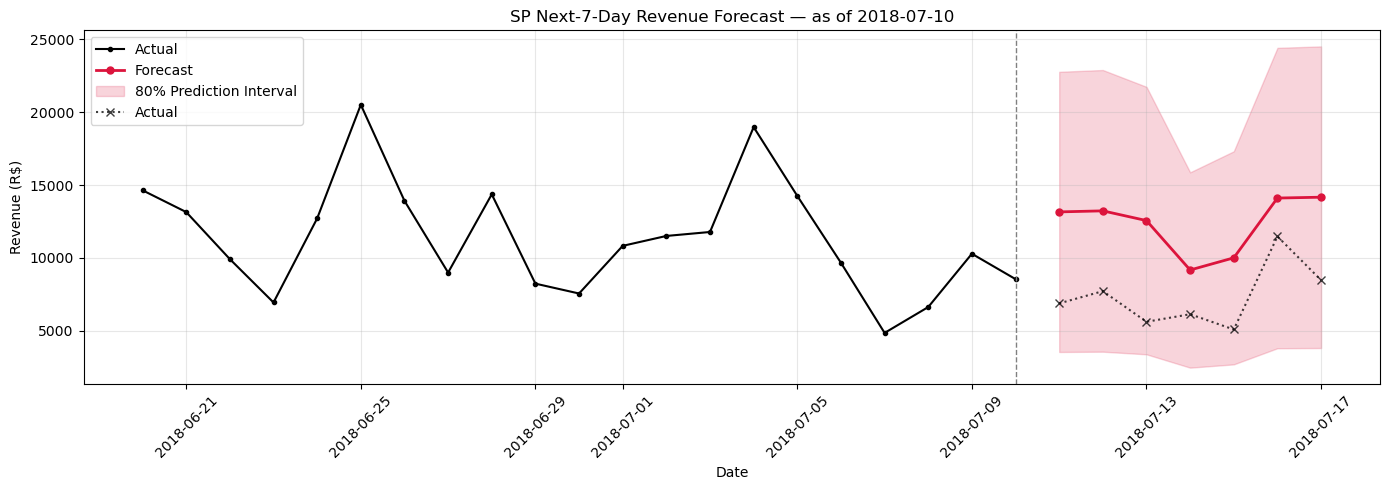


=== SP 2018-07 projected close ===
  Projected 366,599 / Actual 371,821 / Error 1.40% / vs. target 93.5%


In [20]:
# =========================================================
# Cell 5 - SP: 7-day trend + month-end pacing
# =========================================================
AS_OF_SP = pd.Timestamp("2018-07-10")

f7_sp = sp["forecast"](AS_OF_SP, 7)
print(f"=== SP next-7-day forecast (as of {AS_OF_SP.date()}, model {sp['BEST']}) ===")
print(f7_sp.round(0).to_string(index=False))
print(f"\n7-day aggregate error rate: {abs(f7_sp['forecast'].sum()-f7_sp['actual'].sum())/f7_sp['actual'].sum()*100:.2f}%")

hist_sp = sp["base"][(sp["base"]["order_date"] > AS_OF_SP - pd.Timedelta(days=21)) &
                     (sp["base"]["order_date"] <= AS_OF_SP)]
plt.figure(figsize=(14, 5))
plt.plot(hist_sp["order_date"], hist_sp["daily_revenue"], color="black", marker="o", ms=3, label="Actual")
plt.plot(f7_sp["target_date"], f7_sp["forecast"], color="crimson", marker="o", ms=5, lw=2, label="Forecast")
plt.fill_between(f7_sp["target_date"], f7_sp["lower_bound"], f7_sp["upper_bound"], color="crimson", alpha=0.18,
                 label="80% Prediction Interval")
plt.plot(f7_sp["target_date"], f7_sp["actual"], color="black", ls=":", marker="x", ms=6, alpha=0.75, label="Actual")
plt.axvline(AS_OF_SP, color="gray", ls="--", lw=1)
plt.title(f"SP Next-7-Day Revenue Forecast — as of {AS_OF_SP.date()}")
plt.xlabel("Date"); plt.ylabel("Revenue (R$)")
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

prev_month_sp = sp["base"].loc[sp["base"]["order_date"].dt.to_period("M") == pd.Period("2018-06"),
                               "daily_revenue"].sum()
pacing_sp = sp["month_pacing"]("2018-07-10", target=prev_month_sp)
print(f"\n=== SP 2018-07 projected close ===")
print(f"  Projected {pacing_sp['projected_close']:,.0f} / Actual {pacing_sp['actual_close']:,.0f} / "
      f"Error {pacing_sp['error_rate_pct']:.2f}% / vs. target {pacing_sp['vs_target_pct']:.1f}%")

## Run MG (decide whether to proceed after reviewing SP's results)

Set `RUN_MG = True` to run it. Reuses the exact same functions as SP - only the region code differs.

In [22]:
# =========================================================
# Cell 6 - Run the MG pipeline (optional)
# =========================================================
RUN_MG = True

if RUN_MG:
    mg = build_regional_pipeline("MG", "Minas Gerais")

    AS_OF_MG = pd.Timestamp("2018-07-10")
    f7_mg = mg["forecast"](AS_OF_MG, 7)
    print(f"=== MG next-7-day forecast (as of {AS_OF_MG.date()}, model {mg['BEST']}) ===")
    print(f7_mg.round(0).to_string(index=False))
    print(f"\n7-day aggregate error rate: {abs(f7_mg['forecast'].sum()-f7_mg['actual'].sum())/f7_mg['actual'].sum()*100:.2f}%")

    prev_month_mg = mg["base"].loc[mg["base"]["order_date"].dt.to_period("M") == pd.Period("2018-06"),
                                   "daily_revenue"].sum()
    pacing_mg = mg["month_pacing"]("2018-07-10", target=prev_month_mg)
    print(f"\n=== MG 2018-07 projected close ===")
    print(f"  Projected {pacing_mg['projected_close']:,.0f} / Actual {pacing_mg['actual_close']:,.0f} / "
          f"Error {pacing_mg['error_rate_pct']:.2f}% / vs. target {pacing_mg['vs_target_pct']:.1f}%")

    # ---- SP vs MG comparison ----
    compare = pd.DataFrame({
        "SP": [sp["BEST"], sp["summary"].loc[sp["BEST"], "wmape_overall"], sp["INFLATION"]],
        "MG": [mg["BEST"], mg["summary"].loc[mg["BEST"], "wmape_overall"], mg["INFLATION"]],
    }, index=["Selected Model", "WMAPE(%)", "Safety Margin"])
    print("\n=== SP vs MG comparison ===")
    print(compare.to_string())

[Minas Gerais] long: 17,081 rows, origin-date range 2017-02-01 ~ 2018-08-20
[Minas Gerais] 16 CV origin dates -> winner: expected (WMAPE 34.74%)
            wmape_overall
expected            34.74
HGB_ratio           36.96
HGB_log             37.37
HGB_global          38.39
snaive              43.71
naive               53.65
[Minas Gerais] Safety-margin multiplier: 1.12x
[Minas Gerais] Pipeline complete (47s)

=== MG next-7-day forecast (as of 2018-07-10, model expected) ===
target_date  h  forecast  lower_bound  upper_bound  actual  error_rate_pct  within_interval
 2018-07-11  1    3896.0       1237.0       6555.0   838.0           365.0            False
 2018-07-12  2    4093.0       1300.0       6887.0  1254.0           226.0            False
 2018-07-13  3    3773.0       1198.0       6348.0  3551.0             6.0             True
 2018-07-14  4    2649.0        841.0       4458.0  3644.0            27.0             True
 2018-07-15  5    2932.0        931.0       4933.0  5916.0  

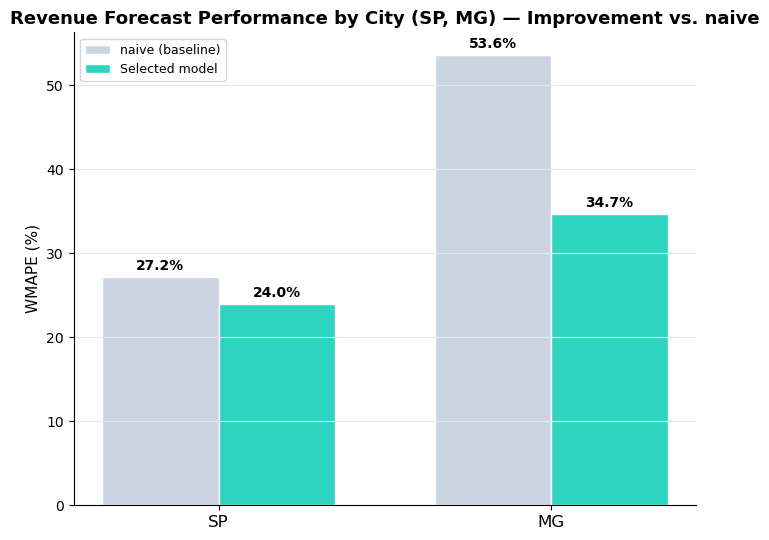

In [23]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

sp_naive = sp['summary'].loc['naive', 'wmape_overall']
sp_best  = sp['summary'].loc[sp['BEST'], 'wmape_overall']
mg_naive = mg['summary'].loc['naive', 'wmape_overall']
mg_best  = mg['summary'].loc[mg['BEST'], 'wmape_overall']

labels = ['SP', 'MG']
naive_vals = [sp_naive, mg_naive]
best_vals  = [sp_best, mg_best]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5.5))
bars1 = ax.bar(x - width/2, naive_vals, width, color='#CBD5E1', edgecolor='white', label='naive (baseline)')
bars2 = ax.bar(x + width/2, best_vals, width, color='#2DD4BF', edgecolor='white', label='Selected model')

for b in list(bars1) + list(bars2):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.8, f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('WMAPE (%)', fontsize=11)
ax.set_title('Revenue Forecast Performance by City (SP, MG) — Improvement vs. naive', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', color='#E2E8F0', linewidth=0.8, zorder=0)

plt.tight_layout()
plt.show()

## Limitations and notes

- Regional data has a smaller sample than total revenue, so the minimum CV-origin sample
  was relaxed from 500 to 200. Validation stability may be lower than the total-revenue model as a result.
- MG already had a weaker signal than SP in the earlier experiment (1-step RandomForest,
  R²=0.245 vs. 0.412). Switching to v2 may bring limited improvement, and if so,
  "MG doesn't improve much even under v2" is itself a valid conclusion.
- The conformal interval buckets (`hb`) may fall back to the global value more often due to
  small samples, so per-horizon interval precision may be coarser than the total-revenue model.

In [ ]:
'''DASH = r'C:\Users\Peter\Desktop\olist_dashboard\data\sales'
import os; os.makedirs(DASH, exist_ok=True)

regions = [sp]
if 'mg' in dir():
    regions.append(mg)

rows_pac, rows_f7 = [], []
for reg in regions:
    LAST_DATE_R = reg['base']['order_date'].max()
    prev_month_target_r = reg['base'].loc[
        reg['base']['order_date'].dt.to_period('M') == (LAST_DATE_R.to_period('M') - 1),
        'daily_revenue'].sum()

    r = reg['month_pacing_beyond'](LAST_DATE_R, target=prev_month_target_r)
    r['region'] = reg['state_name']
    rows_pac.append(r)

    f = reg['forecast_beyond'](LAST_DATE_R, n_days=7).copy()
    f['region'] = reg['state_name']
    rows_f7.append(f)

pd.DataFrame(rows_pac).to_csv(f'{DASH}/regional_pacing.csv', index=False, encoding='utf-8-sig')
pd.concat(rows_f7).to_csv(f'{DASH}/regional_7d.csv', index=False, encoding='utf-8-sig')
print('Regional export done (as of:', LAST_DATE_R.date(), ')')'''

In [ ]:
'''# --- Regional historical (daily) actuals export ---
rows_actual = []
for reg in regions:
    a = reg['base'][['order_date', 'daily_revenue']].copy()
    a['region'] = reg['state_name']
    rows_actual.append(a)

pd.concat(rows_actual).to_csv(f'{DASH}/regional_daily_actual.csv', index=False, encoding='utf-8-sig')
print('Regional historical-actuals export done')'''